In [ ]:
!pip install kagglehub pandas scikit-learn nltk seaborn matplotlib

In [ ]:
import kagglehub
import pandas as pd
import os
import nltk
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.utils import resample

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
path = kagglehub.dataset_download("nicapotato/womens-ecommerce-clothing-reviews")

files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]

data = pd.read_csv(os.path.join(path, csv_file))

print("Jumlah data:", len(data))
data.head()

100%|██████████| 2.79M/2.79M [00:00<00:00, 80.2MB/s]

Extracting files...


Jumlah data: 23486


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [ ]:
data = data[['Review Text', 'Rating']]

# Hanya hapus review kosong
data = data.dropna(subset=['Review Text'])

def label_sentimen(rating):
    if rating == 5:
        return 'positif'
    elif rating == 4:
        return 'netral'
    else:
        return 'negatif'

data['Sentimen'] = data['Rating'].apply(label_sentimen)

print("Distribusi sebelum balancing:")
print(data['Sentimen'].value_counts())

Distribusi sebelum balancing:
Sentimen
positif    12540
negatif     5193
netral      4908
Name: count, dtype: int64


In [ ]:
data_positif = data[data['Sentimen'] == 'positif']
data_netral = data[data['Sentimen'] == 'netral']
data_negatif = data[data['Sentimen'] == 'negatif']

min_jumlah = min(len(data_positif), len(data_netral), len(data_negatif))

data_positif = resample(data_positif, n_samples=min_jumlah, random_state=42)
data_netral = resample(data_netral, n_samples=min_jumlah, random_state=42)
data_negatif = resample(data_negatif, n_samples=min_jumlah, random_state=42)

data = pd.concat([data_positif, data_netral, data_negatif])

print("\nDistribusi setelah balancing:")
print(data['Sentimen'].value_counts())


Distribusi setelah balancing:
Sentimen
positif    4908
netral     4908
negatif    4908
Name: count, dtype: int64


In [ ]:
stop_words = set(stopwords.words('english'))

negation_words = {'not', 'no', 'never', "don't", "isn't", "wasn't", "aren't", "won't"}
stop_words = stop_words - negation_words

def preprocess(text):
    text = text.lower()

    # Gabungkan kata negasi
    text = text.replace("not good", "not_good")
    text = text.replace("not bad", "not_bad")
    text = text.replace("not worth", "not_worth")
    text = text.replace("very good", "very_good")
    text = text.replace("very bad", "very_bad")

    text = re.sub(r'[^a-zA-Z_]', ' ', text)

    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

data['clean_text'] = data['Review Text'].apply(preprocess)

In [ ]:
tfidf = TfidfVectorizer(
    ngram_range=(1,3),
    max_features=10000,
    min_df=3,
    max_df=0.85,
    sublinear_tf=True
)

X = tfidf.fit_transform(data['clean_text'])
y = data['Sentimen']

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(chi2, k=3000)
X = selector.fit_transform(X, y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
model = MultinomialNB(alpha=0.1)
model.fit(X_train, y_train)

MultinomialNB(alpha=0.1)

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7616298811544991

Classification Report:

              precision    recall  f1-score   support

     negatif       0.81      0.84      0.83       981
      netral       0.69      0.67      0.68       982
     positif       0.78      0.77      0.78       982

    accuracy                           0.76      2945
   macro avg       0.76      0.76      0.76      2945
weighted avg       0.76      0.76      0.76      2945



In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7616298811544991


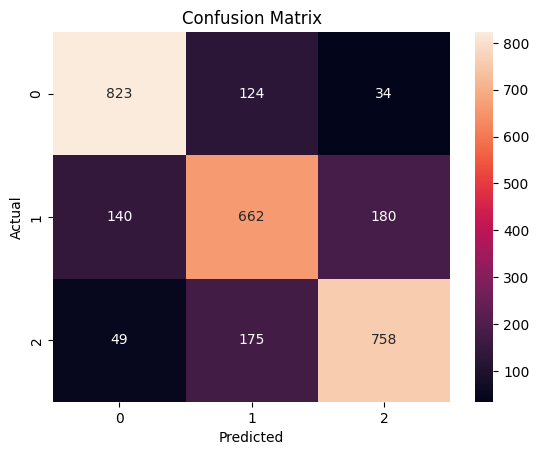

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
def prediksi_review(text):
    text_clean = preprocess(text)
    text_tfidf = tfidf.transform([text_clean])
    text_selected = selector.transform(text_tfidf)
    prediction = model.predict(text_selected)
    return prediction[0]

In [ ]:
test_reviews = [
    "This dress is beautiful and very comfortable",
    "The material is bad and very disappointing",
    "Not worth it",
    "This is not good",
    "I really love this product",
    "Terrible quality and waste of money",
    "It is okay, nothing special"
]

for review in test_reviews:
    print("Review :", review)
    print("Sentimen:", prediksi_review(review))
    print("-" * 40)

Review : This dress is beautiful and very comfortable
Sentimen: positif
----------------------------------------
Review : The material is bad and very disappointing
Sentimen: negatif
----------------------------------------
Review : Not worth it
Sentimen: negatif
----------------------------------------
Review : This is not good
Sentimen: negatif
----------------------------------------
Review : I really love this product
Sentimen: netral
----------------------------------------
Review : Terrible quality and waste of money
Sentimen: negatif
----------------------------------------
Review : It is okay, nothing special
Sentimen: negatif
----------------------------------------


In [ ]:
while True:
    user_input = input("Masukkan review (ketik 'exit' untuk keluar): ")
    if user_input.lower() == 'exit':
        break

    hasil = prediksi_review(user_input)
    print("Sentimen:", hasil)
    print()

Masukkan review (ketik 'exit' untuk keluar): This top is so cute, but it is massively babydoll shaped (a- line) which is not apparent from the pi...
Sentimen: negatif

Masukkan review (ketik 'exit' untuk keluar): Why do designers keep making crop tops??!! i can't imagine this would be flattering on anyone, espec...
Sentimen: negatif

Masukkan review (ketik 'exit' untuk keluar): I have a short torso and this works well for me. 34c, bought the 0. there's not much stretch to the ...
Sentimen: positif

Masukkan review (ketik 'exit' untuk keluar): I love this top. it is loose and comfortable. it is not sheer so you don't need a cami. it runs a li...
Sentimen: netral

Masukkan review (ketik 'exit' untuk keluar): Love the color and style, but material snags easily
Sentimen: negatif

Masukkan review (ketik 'exit' untuk keluar): I absolutely love this bib tee! it's probably my favorite retailer purchase of all time. i'm 5'7", 1...
Sentimen: positif

Masukkan review (ketik 'exit' untuk keluar): 